<a href="https://colab.research.google.com/github/lyhour2/HI_Small_Trans_EDA/blob/main/IBM_AMLSim_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# @title
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_acc = pd.read_csv('/content/drive/MyDrive/IBM_AMLSim/accounts.csv')
df_acc.head(5)

,ACCOUNT_ID,CUSTOMER_ID,INIT_BALANCE,COUNTRY,ACCOUNT_TYPE,IS_FRAUD,TX_BEHAVIOR_ID
0,0,C_0,184.44,US,I,False,1
1,1,C_1,175.80,US,I,False,1
2,2,C_2,142.06,US,I,False,1
3,3,C_3,125.89,US,I,False,1
4,4,C_4,151.13,US,I,False,1


In [ ]:
df_al = pd.read_csv('/content/drive/MyDrive/IBM_AMLSim/alerts.csv')
df_al.head(5)

,ALERT_ID,ALERT_TYPE,IS_FRAUD,TX_ID,SENDER_ACCOUNT_ID,RECEIVER_ACCOUNT_ID,TX_TYPE,TX_AMOUNT,TIMESTAMP
0,193,fan_in,True,82,6976,9739,TRANSFER,4.85,0
1,377,cycle,True,949,5776,2570,TRANSFER,10.27,0
2,189,fan_in,True,6280,9999,9530,TRANSFER,2.74,1
3,377,cycle,True,7999,1089,7352,TRANSFER,10.27,1
4,130,fan_in,True,12975,7025,9708,TRANSFER,3.53,2


In [ ]:
df_trn = pd.read_csv('/content/drive/MyDrive/IBM_AMLSim/transactions.csv')
df_trn.head(5)

,TX_ID,SENDER_ACCOUNT_ID,RECEIVER_ACCOUNT_ID,TX_TYPE,TX_AMOUNT,TIMESTAMP,IS_FRAUD,ALERT_ID
0,1,6456,9069,TRANSFER,465.05,0,False,-1
1,2,7516,9543,TRANSFER,564.64,0,False,-1
2,3,2445,9356,TRANSFER,598.94,0,False,-1
3,4,2576,4617,TRANSFER,466.07,0,False,-1
4,5,3524,1773,TRANSFER,405.63,0,False,-1


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/IBM_AMLSim/IBM_AMLSim_Extracted.csv')
df.head()

Mounted at /content/drive


,Is_Laundering,Sender_Account,Receiver_Account,Payment_Type,Amount,Receiver_Currency,Sender_Currency,Sender_Bank_Location,Receiver_Bank_Location,Date,Time,Laundering_Type
0,0,2445,9356,TRANSFER,598.94,USD,USD,US,US,01/01/2025,12:52:59,normal
1,0,2576,4617,TRANSFER,466.07,USD,USD,US,US,01/01/2025,17:58:30,normal
2,0,3524,1773,TRANSFER,405.63,USD,USD,US,US,01/01/2025,03:13:33,normal
3,0,382,8211,TRANSFER,0.00,USD,USD,US,US,01/01/2025,10:12:15,normal
4,0,4705,9310,TRANSFER,177.47,USD,USD,US,US,01/01/2025,17:20:40,normal


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 12 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Is_Laundering           1048575 non-null  int64  
 1   Sender_Account          1048575 non-null  int64  
 2   Receiver_Account        1048575 non-null  int64  
 3   Payment_Type            1048575 non-null  object 
 4   Amount                  1048575 non-null  float64
 5   Receiver_Currency       1048575 non-null  object 
 6   Sender_Currency         1048575 non-null  object 
 7   Sender_Bank_Location    1048575 non-null  object 
 8   Receiver_Bank_Location  1048575 non-null  object 
 9   Date                    1048575 non-null  object 
 10  Time                    1048575 non-null  object 
 11  Laundering_Type         1048575 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 96.0+ MB


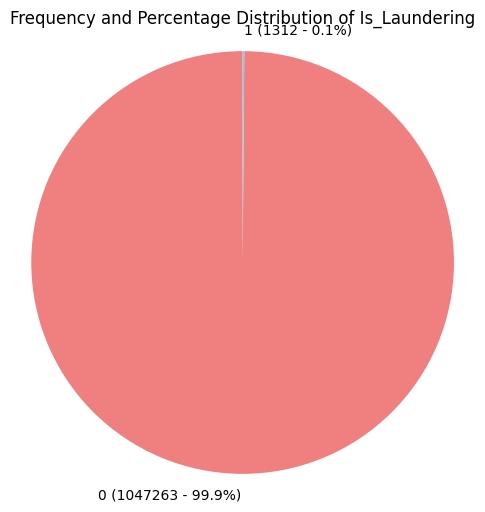

In [ ]:
# @title
source_of_money_counts = df['Is_Laundering'].value_counts()
source_of_money_percentages = df['Is_Laundering'].value_counts(normalize=True) * 100

labels = [f'{label} ({source_of_money_counts[label]} - {percentage:.1f}%)'
          for label, percentage in source_of_money_percentages.items()]

plt.figure(figsize=(6, 6))
plt.pie(source_of_money_percentages,
        labels=labels,
        autopct='',
        colors=['lightcoral', 'skyblue'],
        startangle=90)
plt.title('Frequency and Percentage Distribution of Is_Laundering')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
df['Laundering_Type'].value_counts()

,count
Laundering_Type,
normal,1047263
cycle,720
fan_in,592


/tmp/ipykernel_654/3985727011.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Laundering_Type', y='Count', data=laundering_type_counts, palette=custom_palette)


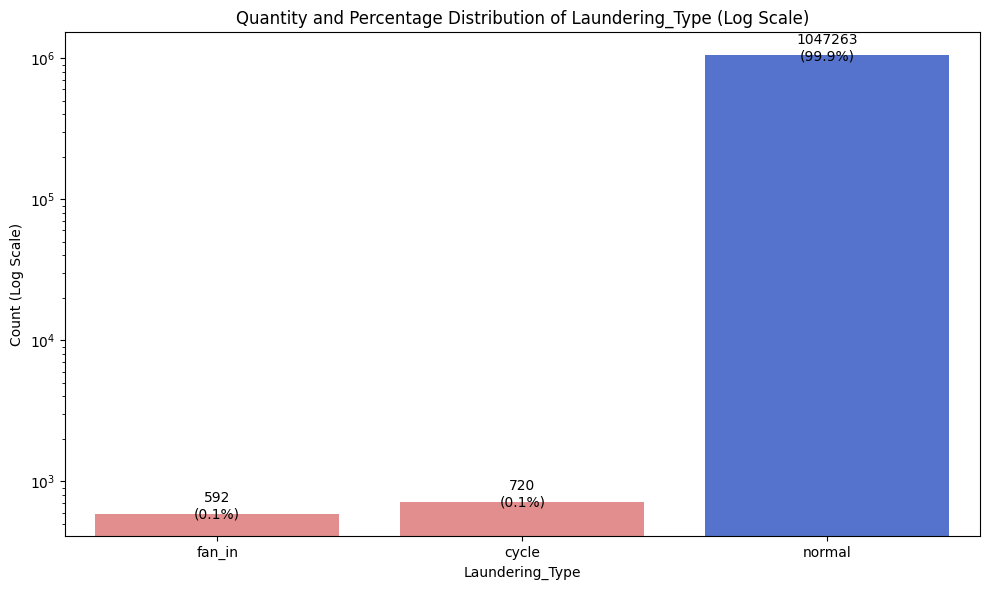

In [ ]:
laundering_type_counts = df['Laundering_Type'].value_counts().reset_index()
laundering_type_counts.columns = ['Laundering_Type', 'Count']

# Calculate percentages
laundering_type_counts['Percentage'] = (laundering_type_counts['Count'] / laundering_type_counts['Count'].sum()) * 100

laundering_type_counts = laundering_type_counts.sort_values(by='Count', ascending=True)

custom_palette = {'fan_in':'lightcoral', 'cycle': 'lightcoral', 'normal': 'royalblue'}

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Laundering_Type', y='Count', data=laundering_type_counts, palette=custom_palette)

# Apply logarithmic scale to the y-axis
plt.yscale('log')

# Add quantity and percentage labels on top of each bar
for p in ax.patches:
    count = int(p.get_height())
    # Ensure we use the correct percentage for the bar
    # The x-coordinate of the bar `p.get_x() + 0.5` corresponds to the index of the sorted DataFrame
    # We need to map this back to the correct row based on Laundering_Type
    laundering_type = laundering_type_counts.iloc[int(p.get_x() + 0.5)]['Laundering_Type']
    percentage = laundering_type_counts.loc[laundering_type_counts['Laundering_Type'] == laundering_type, 'Percentage'].values[0]

    ax.annotate(f'{count}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5), # Adjusted xytext for log scale
                textcoords='offset points')

plt.title('Quantity and Percentage Distribution of Laundering_Type (Log Scale)')
plt.xlabel('Laundering_Type')
plt.ylabel('Count (Log Scale)')
plt.tight_layout()
plt.show()

In [ ]:
df['Payment_Type'].value_counts()

,count
Payment_Type,
TRANSFER,1048575


In [ ]:
df['Sender_Bank_Location'].value_counts()

,count
Sender_Bank_Location,
US,1048575


In [ ]:
df['Receiver_Bank_Location'].value_counts()

,count
Receiver_Bank_Location,
US,1048575


In [ ]:
highest_amount_transactions = df.sort_values(by='Amount', ascending=False).head(10)
display(highest_amount_transactions)

,Is_Laundering,Sender_Account,Receiver_Account,Payment_Type,Amount,Receiver_Currency,Sender_Currency,Sender_Bank_Location,Receiver_Bank_Location,Date,Time,Laundering_Type
575428,0,1332,9415,TRANSFER,21474836.47,USD,USD,US,US,28/06/2025,16:59:38,normal
575210,0,4204,9873,TRANSFER,21474836.47,USD,USD,US,US,28/06/2025,13:46:30,normal
575063,0,1381,9883,TRANSFER,21474836.47,USD,USD,US,US,28/06/2025,22:40:15,normal
575698,0,358,9777,TRANSFER,21474836.47,USD,USD,US,US,28/06/2025,15:32:59,normal
574802,0,311,3071,TRANSFER,21474836.47,USD,USD,US,US,28/06/2025,19:01:31,normal
574890,0,2354,5077,TRANSFER,21474836.47,USD,USD,US,US,28/06/2025,21:04:32,normal
574977,0,5365,7919,TRANSFER,21474836.47,USD,USD,US,US,28/06/2025,16:22:06,normal
574744,0,2273,4268,TRANSFER,21474836.47,USD,USD,US,US,28/06/2025,01:22:07,normal
574663,0,6345,9655,TRANSFER,21474836.47,USD,USD,US,US,27/06/2025,08:20:09,normal
574719,0,6299,7978,TRANSFER,21474836.47,USD,USD,US,US,28/06/2025,17:20:13,normal


/tmp/ipykernel_1074/3241335769.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Country', y='Count', data=country_count, palette='Blues')


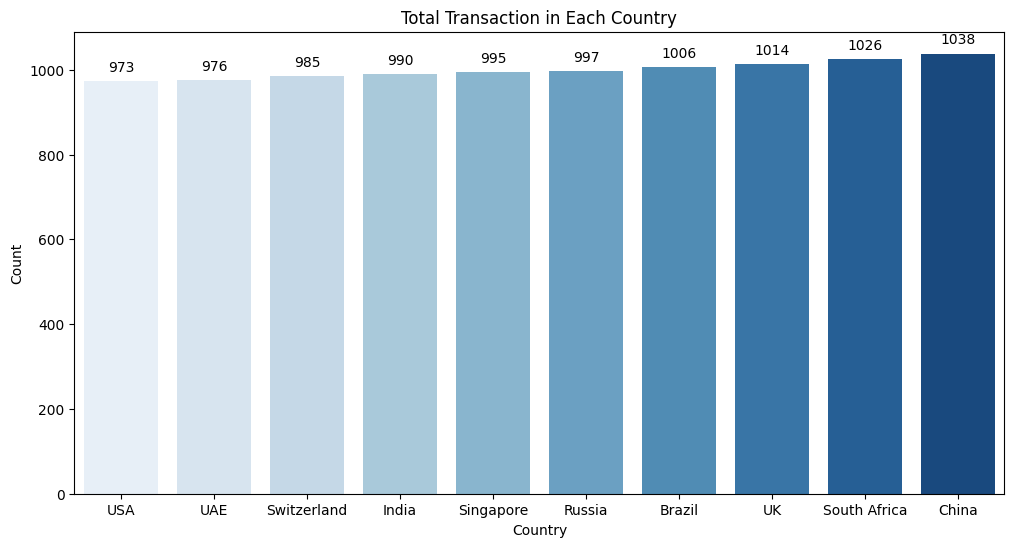

In [ ]:
# @title

country_count = df['Country'].value_counts().reset_index()
country_count.columns = ['Country', 'Count']

# Sort by 'Count' in ascending order to display from left to right
country_count = country_count.sort_values(by='Count', ascending=True)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Country', y='Count', data=country_count, palette='Blues')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points')

plt.title('Total Transaction in Each Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

In [ ]:
highest_amount_transactions_20 = df.sort_values(by='Amount', ascending=False).head(30)
display(highest_amount_transactions_20)

,Is_Laundering,Sender_Account,Receiver_Account,Payment_Type,Amount,Receiver_Currency,Sender_Currency,Sender_Bank_Location,Receiver_Bank_Location,Date,Time,Laundering_Type
575428,0,1332,9415,TRANSFER,21474836.47,USD,USD,US,US,28/06/2025,16:59:38,normal
575210,0,4204,9873,TRANSFER,21474836.47,USD,USD,US,US,28/06/2025,13:46:30,normal
575063,0,1381,9883,TRANSFER,21474836.47,USD,USD,US,US,28/06/2025,22:40:15,normal
575698,0,358,9777,TRANSFER,21474836.47,USD,USD,US,US,28/06/2025,15:32:59,normal
574802,0,311,3071,TRANSFER,21474836.47,USD,USD,US,US,28/06/2025,19:01:31,normal
574890,0,2354,5077,TRANSFER,21474836.47,USD,USD,US,US,28/06/2025,21:04:32,normal
574977,0,5365,7919,TRANSFER,21474836.47,USD,USD,US,US,28/06/2025,16:22:06,normal
574744,0,2273,4268,TRANSFER,21474836.47,USD,USD,US,US,28/06/2025,01:22:07,normal
574663,0,6345,9655,TRANSFER,21474836.47,USD,USD,US,US,27/06/2025,08:20:09,normal
574719,0,6299,7978,TRANSFER,21474836.47,USD,USD,US,US,28/06/2025,17:20:13,normal


/tmp/ipykernel_654/1741794620.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=highest_amount_transactions_20.index, y='Amount', data=highest_amount_transactions_20, palette='viridis')


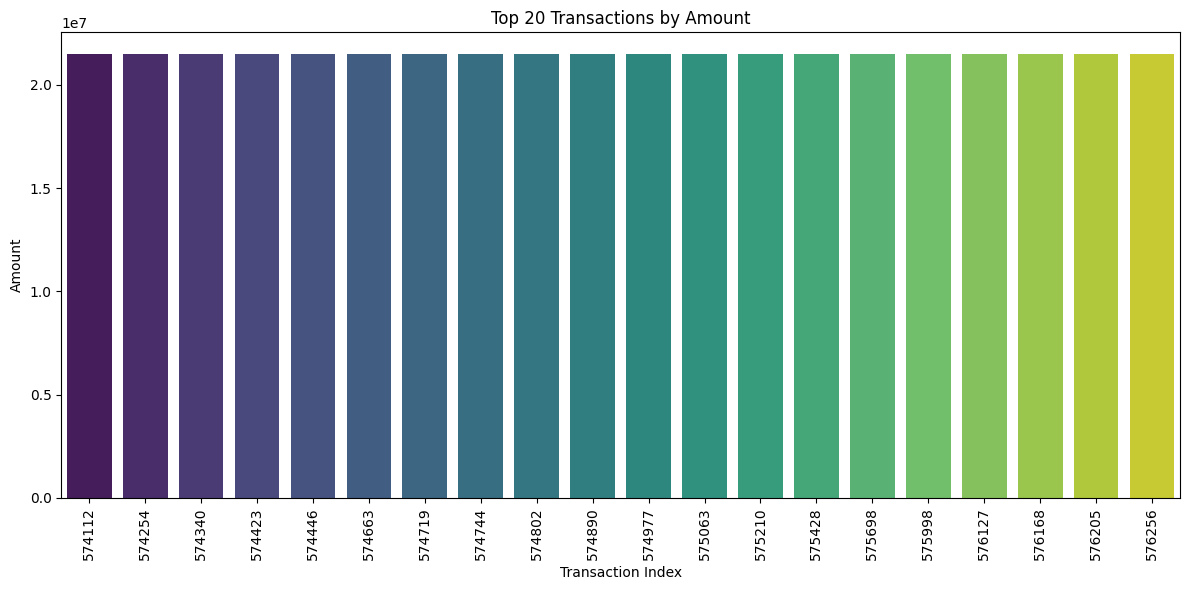

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=highest_amount_transactions_20.index, y='Amount', data=highest_amount_transactions_20, palette='viridis')
plt.title('Top 20 Transactions by Amount')
plt.xlabel('Transaction Index')
plt.ylabel('Amount')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()